**Ανάλυση Αποχωρήσεων Πελατών (Customer Churn) σε Τηλεπικοινωνιακό Πάροχο με χρήση Apache Spark**

*Ομαδική Εργασία στα πλαίσια μαθήματος Big Data:*

* **Ονοματεπώνυμο 1:** [Θεόδωρος Παναγιωτίδης] (ΑΜ: ics22071)
* **Ονοματεπώνυμο 2:** [Αλίκη Μπλιώνα] (ΑΜ: ics23099)

In [47]:
# Βιβλιοθήκες
import sys
import os

# Πακέτα για Spark
!pip install pyspark
!apt install openjdk-8-jdk

# Imports για Spark και Colab
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit, avg, count, isnan
from google.colab import files

print("Python version:", sys.version)
print("Libraries installed and imported successfully.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-8-jdk is already the newest version (8u472-ga-1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Libraries installed and imported successfully.


**ΘΕΜΑ 1**


In [48]:
# 1.1

# Έναρξη Spark Session
spark = SparkSession.builder.appName("Churn_Quick_Setup").getOrCreate()

# Διάβασμα του αρχείου csv
uploaded = files.upload()

# Εκτύπωση για επιβεβαίωση
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

file_name = "telecom_churn_10k.csv"

# Διάβασμα αρχείου σε DataFrame
df = spark.read.csv(file_name, header=True, inferSchema=True)

# Εμφάνιση 10 γραμμών, σχήμα και συνολικό αριθμό εγγραφών
print("First 10 rows")
df.show(10)
print("DataFrame Schema")
df.printSchema()
numofrows = df.count()
print(f"Total Record Count: {numofrows}")

Saving telecom_churn_10k.csv to telecom_churn_10k (3).csv
User uploaded file "telecom_churn_10k (3).csv" with length 768521 bytes
First 10 rows
+-----------+------+----+-------+-------------+--------------+------------+----------+------+---------------+-------------+--------------+-------------+--------------+-----+
|CUSTOMER_ID|GENDER| AGE|COUNTRY|TENURE_MONTHS| CONTRACT_TYPE|HAS_INTERNET|HAS_MOBILE|HAS_TV|MONTHLY_CHARGES|TOTAL_CHARGES|NUM_COMPLAINTS|SUPPORT_CALLS|PAYMENT_METHOD|CHURN|
+-----------+------+----+-------+-------------+--------------+------------+----------+------+---------------+-------------+--------------+-------------+--------------+-----+
|    C000001|  Male|68.0|     FR|         61.0|Month-to-month|           0|         1|     0|          17.54|      1077.63|             0|            0| Bank transfer|  1.0|
|    C000002|Female|65.0|     FR|         NULL|Month-to-month|           1|         1|     0|          50.82|       833.94|             1|            1|   Credi

In [49]:
# 1.2

# Υπολογισμός missing values ανά στήλη
missing_data_list = []

for c in df.columns:

  # Μετατροπή λίστας σε λεξικό
  dtype = dict(df.dtypes)[c]

  if dtype in ['double', 'float', 'int', 'bigint', 'long']:
    missing_count = df.filter(col(c).isNull() | isnan(col(c))).count()
  else:
    missing_count = df.filter(col(c).isNull()).count()

  if missing_count > 0:
    missing_data_list.append((c, missing_count))

df_missing = spark.createDataFrame(missing_data_list, ["column_name", "missing_count"])

if missing_data_list:
    df_missing = spark.createDataFrame(missing_data_list, ["column_name", "missing_count"])
    print("Missing Values Report:")
    df_missing.orderBy(col("missing_count").desc()).show(truncate=False)
else:
    print("No Missing Values Found")

Missing Values Report:
+---------------+-------------+
|column_name    |missing_count|
+---------------+-------------+
|AGE            |300          |
|MONTHLY_CHARGES|300          |
|TENURE_MONTHS  |300          |
|TOTAL_CHARGES  |300          |
|CHURN          |300          |
+---------------+-------------+



**Σχολιασμός Ελλιπών Τιμών:**

- CHURN: Είναι η πιο κρίσιμη στήλη καθώς αποτελεί τη μεταβλητή-στόχο για την ταξινόμηση των πελατών. Ελλιπείς τιμές εδώ σημαίνουν ότι δεν γνωρίζουμε αν o πελάτης έφυγε ή όχι, άρα αυτές oι εγγραφές είναι άχρηστες για την εκπαίδευση του μοντέλου.

- TENURE_MONTHS & CHARGES (Monthly/Total): Αυτά είναι τα σημαντικότερα αριθμητικά features. Τo Tenure δείχνει την πιστότητα, ενώ τα Charges την οικονομική αξία του πελάτη. Αν λείπουν τιμές εδώ, το μοντέλο Παλινδρόμησης δεν θα μπορεί να λειτουργήσει σωστά.

- AGE: Eπηρεάζει λιγότερο άμεσα την οικονομική συμπεριφορά σε σχέση με τα δεδομένα συμβολαίου, ωστόσο πρέπει επίσης να αντιμετωπιστεί για να διατηρηθεί η ακεραιότητα του dataset.



In [50]:
# 1.3

# Διαγραφή γραμμών όπου το CHURN είναι NULL
df_clean = df.na.drop(subset=["CHURN"])
print(f"Record Count after dropping empty CHURN records: {df_clean.count()}")

# Χειρισμός ελλιπών τιμών σε πεδία με χρήση Mean Imputation
stats = df_clean.select(
  avg("AGE").alias("avg_age"),
  avg("TENURE_MONTHS").alias("avg_tenure"),
  avg("MONTHLY_CHARGES").alias("avg_monthly"),
  avg("TOTAL_CHARGES").alias("avg_total")
).collect()[0]

# Αποθήκευση τιμών σε μεταβλητές
mean_age = stats["avg_age"]
mean_tenure = stats["avg_tenure"]
mean_monthly = stats["avg_monthly"]
mean_total = stats["avg_total"]

print(f"Calculated Means -> Age: {mean_age:.1f}, Tenure: {mean_tenure:.1f}, Monthly Charges: {mean_monthly:.1f}, Total Charges: {mean_total:.1f}")

# Filling
fill_values = {
  "AGE": mean_age,
  "TENURE_MONTHS": mean_tenure,
  "MONTHLY_CHARGES": mean_monthly,
  "TOTAL_CHARGES": mean_total
}

df_clean = df_clean.na.fill(fill_values)

# Έλεγχος μετά τον καθαρισμό
print("Checking after cleaning")
for col_name in ["CHURN", "AGE", "TENURE_MONTHS", "MONTHLY_CHARGES", "TOTAL_CHARGES"]:
  cnt = df_clean.filter(col(col_name).isNull()).count()
  print(f"Nulls in {col_name}: {cnt}")

Record Count after dropping empty CHURN records: 9700
Calculated Means -> Age: 51.4, Tenure: 36.6, Monthly Charges: 36.6, Total Charges: 1339.5
Checking after cleaning
Nulls in CHURN: 0
Nulls in AGE: 0
Nulls in TENURE_MONTHS: 0
Nulls in MONTHLY_CHARGES: 0
Nulls in TOTAL_CHARGES: 0


**Τεκμηρίωση Στρατηγικής Καθαρισμού:**

- CHURN: Εφαρμόστηκε διαγραφή των εγγραφών (drop). Καθώς το CHURN αποτελεί τη μεταβλητή-στόχο για την ανάλυση και το μοντέλο μηχανικής μάθησης, η συμπλήρωσή του με τεχνητά μέσα θα μπορούσε να αλλοιώσει την ακρίβεια των προβλέψεων.

- AGE, TENURE, CHARGES: Εφαρμόστηκε συμπλήρωση με τον Μέσο Όρο (Mean). Επιλέξαμε αυτή τη μέθοδο αντί της διαγραφής, ώστε να διατηρήσουμε τον όγκο των δεδομένων και να μην χάσουμε χρήσιμες πληροφορίες από τα υπόλοιπα χαρακτηριστικά των πελατών.






In [51]:
# 1.4

cols_to_analyze = ["AGE", "TENURE_MONTHS", "MONTHLY_CHARGES", "TOTAL_CHARGES"]
print("Basic Statistics - describe()")
# Αυτόματος υπολογισμός count, mean, stddev, min, max μέσω describe()
df_clean.select(cols_to_analyze).describe().show()

print("Average Tenure & Monthly Charges by Churn")
# Ομαδοποίηση βάσει του CHURN και υπολογισμός μέσου όρου (mean) για τη διάρκεια παραμονής και τη χρέωση
df_clean.groupBy("CHURN").mean("TENURE_MONTHS", "MONTHLY_CHARGES").show()

Basic Statistics - describe()
+-------+------------------+------------------+------------------+------------------+
|summary|               AGE|     TENURE_MONTHS|   MONTHLY_CHARGES|     TOTAL_CHARGES|
+-------+------------------+------------------+------------------+------------------+
|  count|              9700|              9700|              9700|              9700|
|   mean| 51.42650653629523|36.559855411439315|36.556964285714315|1339.5033949633366|
| stddev|19.247481813671897|20.466005655823807|11.127497787046334| 875.0902702308767|
|    min|              18.0|               1.0|               5.0|               0.0|
|    max|              85.0|              72.0|             80.45|           5197.62|
+-------+------------------+------------------+------------------+------------------+

Average Tenure & Monthly Charges by Churn
+-----+------------------+--------------------+
|CHURN|avg(TENURE_MONTHS)|avg(MONTHLY_CHARGES)|
+-----+------------------+--------------------+
|  0.0|38

**Παρατηρήσεις Περιγραφικής Ανάλυσης:**

Από τα παραπάνω στατιστικά, παρατηρούμε ότι οι πελάτες που αποχωρούν (CHURN=1) έχουν κατά μέσο όρο μικρότερη διάρκεια παραμονής (TENURE_MONTHS) σε σχέση με τους πιστούς πελάτες, γεγονός που επιβεβαιώνει ότι οι νέοι συνδρομητές είναι πιο επιρρεπείς σε αποχώρηση. Αντίθετα, οι μηνιαίες χρεώσεις (MONTHLY_CHARGES) φαίνεται να είναι υψηλότερες στους πελάτες που έφυγαν. Τέλος, τα συνολικά έσοδα (TOTAL_CHARGES) εμφανίζουν μεγάλη τυπική απόκλιση, κάτι που δικαιολογείται από το μεγάλο εύρος στη διάρκεια των συμβολαίων.



In [52]:
# 1.5

# Δημιουργία νέων πεδίων Feature Engineering
df_clean = df_clean.withColumn("NUM_SERVICES",
                               col("HAS_INTERNET") + col("HAS_MOBILE") + col("HAS_TV"))
df_clean = df_clean.withColumn("IS_LONG_TENURE",
                               when(col("TENURE_MONTHS") >= 24, 1).otherwise(0))
df_clean = df_clean.withColumn("AVG_CHARGE_PER_MONTH",
                               when(col("TENURE_MONTHS") == 0, 0)
                               .otherwise(col("TOTAL_CHARGES") / col("TENURE_MONTHS")))

print("Sample with new columns")
df_clean.select("CUSTOMER_ID", "NUM_SERVICES", "IS_LONG_TENURE", "AVG_CHARGE_PER_MONTH").show(5)

Sample with new columns
+-----------+------------+--------------+--------------------+
|CUSTOMER_ID|NUM_SERVICES|IS_LONG_TENURE|AVG_CHARGE_PER_MONTH|
+-----------+------------+--------------+--------------------+
|    C000001|           1|             1|  17.666065573770492|
|    C000002|           2|             1|   22.81026526541081|
|    C000003|           2|             1|                34.5|
|    C000004|           3|             0|               45.26|
|    C000005|           3|             1|  38.953589743589745|
+-----------+------------+--------------+--------------------+
only showing top 5 rows


**ΘΕΜΑ** **2**

In [53]:
# 2.1

# Δημιουργία προσωρινού view
df_clean.createOrReplaceTempView("churn_view")

# Επιβεβαίωση - Test Query
print("Testing SQL View: First 5 rows")
spark.sql("SELECT CUSTOMER_ID, CHURN, NUM_SERVICES, IS_LONG_TENURE \
           FROM churn_view \
           LIMIT 5").show()

Testing SQL View: First 5 rows
+-----------+-----+------------+--------------+
|CUSTOMER_ID|CHURN|NUM_SERVICES|IS_LONG_TENURE|
+-----------+-----+------------+--------------+
|    C000001|  1.0|           1|             1|
|    C000002|  0.0|           2|             1|
|    C000003|  0.0|           2|             1|
|    C000004|  0.0|           3|             0|
|    C000005|  0.0|           3|             1|
+-----------+-----+------------+--------------+



In [54]:
# 2.2

# 2.2.1
# SUM(CHURN): Επειδή το Churn είναι 0 ή 1, το άθροισμα μας δίνει το πλήθος όσων έφυγαν.
# ROUND(..., 2): Στρογγυλοποίηση σε 2 δεκαδικά ψηφία.
print("Churn Analysis by Contract Type")
query_contract = """
  SELECT
    CONTRACT_TYPE,
    COUNT(*) as Total_Customers,
    SUM(CHURN) as Churned_Customers,
    ROUND((SUM(CHURN) / COUNT(*)) * 100, 2) as Churn_Rate_Percentage
  FROM churn_view
  GROUP BY CONTRACT_TYPE
  ORDER BY Churn_Rate_Percentage DESC
"""
spark.sql(query_contract).show()

# 2.2.2
print("Churn Analysis by Number Of Services")
query_services = """
  SELECT
    NUM_SERVICES,
    COUNT(*) as Total_Customers,
    SUM(CHURN) as Churned_Customers,
    ROUND((SUM(CHURN) / COUNT(*)) * 100, 2) as Churn_Rate_Percentage
  FROM churn_view
  GROUP BY NUM_SERVICES
  ORDER BY NUM_SERVICES ASC
"""
spark.sql(query_services).show()

# 2.2.3
print("Average Monthly Charges by Churn Status")
query_monthly_charged = """
  SELECT
    CHURN,
    ROUND(AVG(MONTHLY_CHARGES), 2) as Avg_Monthly_Charges
  FROM churn_view
  GROUP BY CHURN
  ORDER BY CHURN
"""
spark.sql(query_monthly_charged).show()

# Προαιρετικό ερώτημα - Ομαδοποίηση ανά CONTRACT_TYPE
print("Average Monthly Charges by Contract and Churn Status")
query_monthly_charged_v2 = """
  SELECT
    CONTRACT_TYPE,
    CHURN,
    ROUND(AVG(MONTHLY_CHARGES), 2) as Avg_Monthly_Charges
  FROM churn_view
  GROUP BY CONTRACT_TYPE, CHURN
  ORDER BY CONTRACT_TYPE, CHURN
"""
spark.sql(query_monthly_charged_v2).show()

Churn Analysis by Contract Type
+--------------+---------------+-----------------+---------------------+
| CONTRACT_TYPE|Total_Customers|Churned_Customers|Churn_Rate_Percentage|
+--------------+---------------+-----------------+---------------------+
|Month-to-month|           5326|           2834.0|                53.21|
|      One year|           2440|            503.0|                20.61|
|      Two year|           1934|            264.0|                13.65|
+--------------+---------------+-----------------+---------------------+

Churn Analysis by Number Of Services
+------------+---------------+-----------------+---------------------+
|NUM_SERVICES|Total_Customers|Churned_Customers|Churn_Rate_Percentage|
+------------+---------------+-----------------+---------------------+
|           0|            229|             99.0|                43.23|
|           1|           2149|           1031.0|                47.98|
|           2|           5152|           1926.0|                

In [55]:
# 2.3

# HAVING για φιλτράρισμα μετά την ομαδοποίηση
print("Top 5 Countries with Highest Churn with at least 100 customers")
query_geo_analysis = """
  SELECT
    COUNTRY,
    COUNT(*) as Total_Customers,
    SUM(CHURN) as Churned_Customers,
    ROUND((SUM(CHURN) / COUNT(*)) * 100, 2) as Churn_Rate_Percentage
  FROM churn_view
  GROUP BY COUNTRY
  HAVING Total_Customers >= 100
  ORDER BY Churn_Rate_Percentage DESC
  LIMIT 5
"""
spark.sql(query_geo_analysis).show()

Top 5 Countries with Highest Churn with at least 100 customers
+-------+---------------+-----------------+---------------------+
|COUNTRY|Total_Customers|Churned_Customers|Churn_Rate_Percentage|
+-------+---------------+-----------------+---------------------+
|     IT|           1003|            409.0|                40.78|
|     DE|           1198|            451.0|                37.65|
|     GR|           3732|           1382.0|                37.03|
|     UK|           1560|            564.0|                36.15|
|     ES|           1050|            379.0|                 36.1|
+-------+---------------+-----------------+---------------------+



**2.4**

Με βάση την ανάλυση επιβεβαιώνονται και οι 3 αρχικές επιχειρησιακές υποθέσεις(hints).

Συγκεκριμένα, ως προς τον τύπο συμβολαίου, αποδεικνύεται ότι η έλλειψη δέσμευσης αυξάνει τον κίνδυνο φυγής, καθώς οι πελάτες με Month-to-month συμβόλαιο εμφανίζουν το υψηλότερο ποσοστό churn 53.21%, σε αντίθεση με τους πελάτες Two year που έχουν 13.65%.

Επιπλέον, επιβεβαιώνεται ότι η παροχή πολλαπλών υπηρεσιών λειτουργεί ως παράγοντας συγκράτησης. Οι πελάτες που διαθέτουν πακέτο 3 υπηρεσιών σημειώνουν χαμηλό ποσοστό churn 25.12%, το οποίο είναι σχεδόν το μισό σε σχέση με όσους διαθέτουν μόνο μία υπηρεσία με ποσοστό churn 47.98%.

Τέλος, παρατηρείται συσχέτιση μεταξύ κόστους και αποχώρησης, καθώς οι πελάτες που διέκοψαν τη συνεργασία τους (Churn=1) είχαν κατά μέσο όρο υψηλότερες μηνιαίες χρεώσεις 37.03€ συγκριτικά με τους πιστούς πελάτες 36.27€, επιβεβαιώνοντας ότι το υψηλό κόστος αποτελεί κίνητρο φυγής.

Συμπερασματικά, η εταιρεία θα πρέπει να προωθήσει ετήσια συμβόλαια και συνδυαστικά πακέτα υπηρεσιών για να μειώσει τις αποχωρήσεις.

 Γράφημα Συμβολαίων 


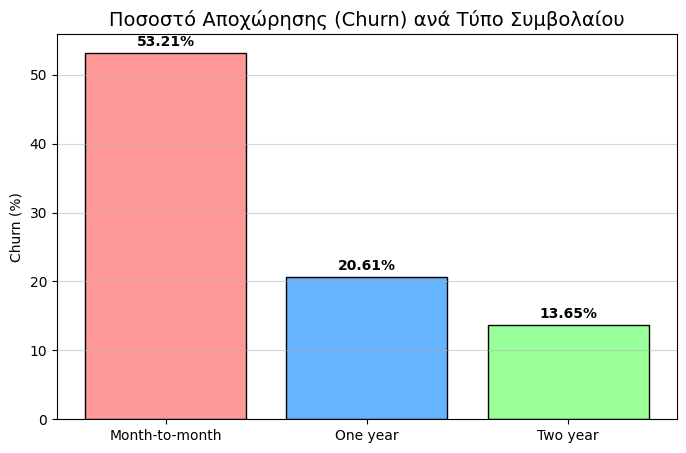


 Γράφημα Υπηρεσιών 


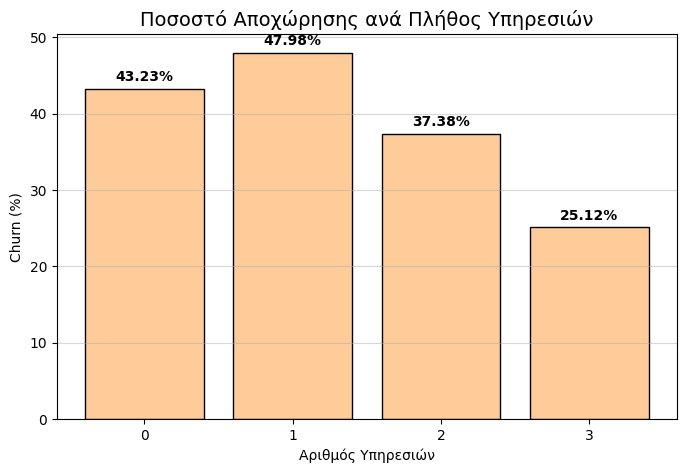


 Γράφημα Χωρών (Top 5) 


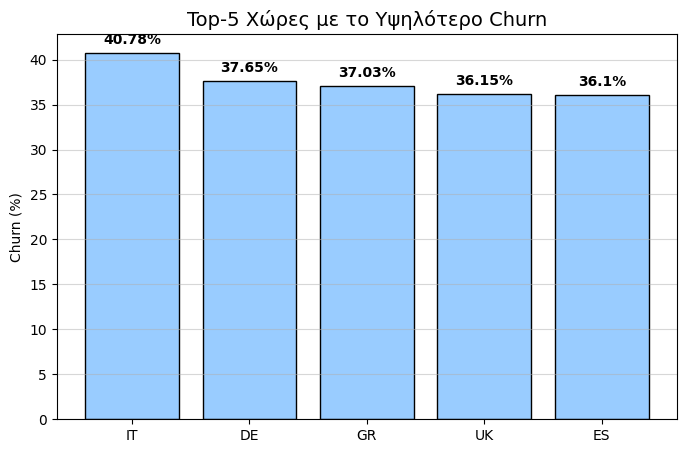

In [56]:
# ΟΠΤΙΚΟΠΟΙΗΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ ΘΕΜΑΤΟΣ 2

import matplotlib.pyplot as plt
import pandas as pd

# Ρύθμιση μεγέθους γραφημάτων
plt.rcParams['figure.figsize'] = [8, 5]

# ΓΡΑΦΗΜΑ 1: Churn ανά Τύπο Συμβολαίου
print(" Γράφημα Συμβολαίων ")
query_contract_viz = """
  SELECT CONTRACT_TYPE, ROUND((SUM(CHURN) / COUNT(*)) * 100, 2) as Churn_Rate
  FROM churn_view GROUP BY CONTRACT_TYPE ORDER BY Churn_Rate DESC
"""
pdf_contract = spark.sql(query_contract_viz).toPandas()

plt.figure()
bars1 = plt.bar(pdf_contract['CONTRACT_TYPE'], pdf_contract['Churn_Rate'], color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
plt.title('Ποσοστό Αποχώρησης (Churn) ανά Τύπο Συμβολαίου', fontsize=14)
plt.ylabel('Churn (%)')
plt.grid(axis='y', alpha=0.5)
# Ετικέτες
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height()}%', ha='center', fontweight='bold')
plt.show()


# ΓΡΑΦΗΜΑ 2: Churn ανά Πλήθος Υπηρεσιών
print("\n Γράφημα Υπηρεσιών ")
query_services_viz = """
  SELECT NUM_SERVICES, ROUND((SUM(CHURN) / COUNT(*)) * 100, 2) as Churn_Rate
  FROM churn_view GROUP BY NUM_SERVICES ORDER BY NUM_SERVICES
"""
pdf_services = spark.sql(query_services_viz).toPandas()

plt.figure()
bars2 = plt.bar(pdf_services['NUM_SERVICES'].astype(str), pdf_services['Churn_Rate'], color='#ffcc99', edgecolor='black')
plt.title('Ποσοστό Αποχώρησης ανά Πλήθος Υπηρεσιών', fontsize=14)
plt.xlabel('Αριθμός Υπηρεσιών')
plt.ylabel('Churn (%)')
plt.grid(axis='y', alpha=0.5)
# Ετικέτες
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height()}%', ha='center', fontweight='bold')
plt.show()


# ΓΡΑΦΗΜΑ 3: Churn ανά Χώρα (Top 5)
print("\n Γράφημα Χωρών (Top 5) ")
query_country_viz = """
  SELECT COUNTRY, ROUND((SUM(CHURN) / COUNT(*)) * 100, 2) as Churn_Rate
  FROM churn_view GROUP BY COUNTRY HAVING COUNT(*) >= 100 ORDER BY Churn_Rate DESC LIMIT 5
"""
pdf_country = spark.sql(query_country_viz).toPandas()

plt.figure()
bars3 = plt.bar(pdf_country['COUNTRY'], pdf_country['Churn_Rate'], color='#99ccff', edgecolor='black')
plt.title('Top-5 Χώρες με το Υψηλότερο Churn', fontsize=14)
plt.ylabel('Churn (%)')
plt.grid(axis='y', alpha=0.5)
# Ετικέτες
for bar in bars3:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height()}%', ha='center', fontweight='bold')
plt.show()

ΘΕΜΑ 3

In [57]:
# Imports
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# 3.1 Επιλογή Features & Target
# Ορίζουμε ποιες στήλες θα χρησιμοποιήσουμε για την πρόβλεψη
categorical_cols = ["CONTRACT_TYPE", "PAYMENT_METHOD", "COUNTRY"]
numeric_cols = ["AGE", "TENURE_MONTHS", "NUM_COMPLAINTS", "SUPPORT_CALLS",
                "HAS_INTERNET", "HAS_MOBILE", "HAS_TV", "NUM_SERVICES"]

# Στόχος είναι να προβλέψουμε το MONTHLY_CHARGES
label_col = "MONTHLY_CHARGES"

# Δημιουργία DataFrame μόνο με τις επιλεγμένες στήλες
selected_cols = categorical_cols + numeric_cols + [label_col]
df_ml = df_clean.select(selected_cols)

print("Features selected for the model:")
print(f"Categorical: {categorical_cols}")
print(f"Numeric: {numeric_cols}")

Features selected for the model:
Categorical: ['CONTRACT_TYPE', 'PAYMENT_METHOD', 'COUNTRY']
Numeric: ['AGE', 'TENURE_MONTHS', 'NUM_COMPLAINTS', 'SUPPORT_CALLS', 'HAS_INTERNET', 'HAS_MOBILE', 'HAS_TV', 'NUM_SERVICES']


In [58]:
# 3.2 Προεπεξεργασία & Pipeline

stages = []

for categoricalCol in categorical_cols:
    # StringIndexer: Μετατροπή κατηγορικών (text) σε αριθμούς (indices)
    stringIndexer = StringIndexer(inputCol=categoricalCol, outputCol=categoricalCol + "_index")
    # OneHotEncoder: Μετατρέπει τους δείκτες σε διανύσματα
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "_vec"])
    stages += [stringIndexer, encoder]

# Vector Assembler
assemblerInputs = [c + "_vec" for c in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

# Decision Tree Regressor (με maxDepth ελέγχουμε πολυπλοκότητα)
dt = DecisionTreeRegressor(featuresCol="features", labelCol=label_col, maxDepth=5)
stages += [dt]

# Δημιουργία Pipeline
pipeline = Pipeline(stages=stages)


In [59]:
# 3.3 Διαχωρισμός Train/Test και Εκπαίδευση

# Χωρίζουμε τα δεδομένα: 70% για εκπαίδευση, 30% για έλεγχο (seed=42 για να έχουμε ιδια αποτελέσματα)
train_data, test_data = df_ml.randomSplit([0.7, 0.3], seed=42)

print("Training the model... ")
model = pipeline.fit(train_data)

print("Making predictions on test set...")
predictions = model.transform(test_data)

# Εμφάνιση δείγματος αποτελεσμάτων
print("Sample Predictions:")
predictions.select("features", label_col, "prediction").show(5)

Training the model... 
Making predictions on test set...
Sample Predictions:
+--------------------+---------------+------------------+
|            features|MONTHLY_CHARGES|        prediction|
+--------------------+---------------+------------------+
|(18,[0,3,7,10,11,...|          21.75|28.732971821756248|
|(18,[0,3,7,10,11,...|          41.47| 39.74414308305269|
|(18,[0,3,7,10,11]...|          35.39|28.732971821756248|
|(18,[0,3,7,10,11,...|          35.45|30.744541993720567|
|(18,[0,3,7,10,11,...|          51.28| 39.74414308305269|
+--------------------+---------------+------------------+
only showing top 5 rows


In [60]:
# 3.4 Αξιολόγηση Μοντέλου

# Υπολογισμός RMSE (Root Mean Squared Error)
evaluator_rmse = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse")
rmse = evaluator_rmse.evaluate(predictions)

# Υπολογισμός R2
evaluator_r2 = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="r2")
r2 = evaluator_r2.evaluate(predictions)

# Αποτελέσματα
print(f"Model Performance Metrics:")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} €")
print(f"R2 (Coefficient of Determination): {r2:.4f}")

Model Performance Metrics:
RMSE (Root Mean Squared Error): 7.95 €
R2 (Coefficient of Determination): 0.5032


**Με βάση την αξιολόγηση του μοντέλου Decision Tree Regressor στο test set, προκύπτουν τα εξής συμπεράσματα:**

* Σφάλμα Πρόβλεψης (RMSE): Το Root Mean Squared Error υπολογίστηκε στα 7.95€.
* Ερμηνευτικότητα (R²): Ο συντελεστής R² είναι περίπου 0.50, υποδεικνύοντας ότι το μοντέλο μας εξηγεί το 50% της μεταβλητότητας των χρεώσεων βάσει των χαρακτηριστικών που επιλέξαμε.

**Επιχειρησιακό Συμπέρασμα:** Το μοντέλο κρίνεται "χονδρικά χρήσιμο" για σκοπούς εκτίμησης. Το σφάλμα των ~8€ είναι αρκετά χαμηλό ώστε να δώσει στον πάροχο μια ρεαλιστική τάξη μεγέθους για τα έσοδα που αναμένονται από έναν νέο πελάτη. Ωστόσο, δεν έχει την απόλυτη ακρίβεια που θα απαιτούνταν για αυστηρή, αυτοματοποιημένη τιμολόγηση χωρίς ανθρώπινη επίβλεψη, καθώς σε χαμηλούς λογαριασμούς (π.χ. 20€) μια απόκλιση 8€ είναι σημαντική.